# PyTorch Pretrained Models - Image Classification

## Setup

In [48]:
# Set up Kaggle API credentials for downloading datasets
import os  # For file and directory operations
import shutil  # For file copying

kaggle_json_path = './kaggle.json'  # Path to your Kaggle API key
kaggle_dir = os.path.expanduser('~/.kaggle')  # Default Kaggle directory
os.makedirs(kaggle_dir, exist_ok=True)  # Create directory if it doesn't exist
shutil.copy(kaggle_json_path, os.path.join(kaggle_dir, 'kaggle.json'))  # Copy API key
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)  # Set permissions
print('Kaggle API key set up successfully.')

Kaggle API key set up successfully.


In [49]:
# Install and import opendatasets, then download the bean leaf lesions dataset from Kaggle
!pip install -q opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Skipping, found downloaded files in ".\bean-leaf-lesions-classification" (use force=True to force download)


## Imports

In [50]:
# Third-party libraries
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd
import torch
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from torchvision import transforms

# Reproducibility
torch.manual_seed(42)

# Set device to GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")


PyTorch version: 2.9.1+rocm7.2.1
Using device: cuda


In [ ]:
# Set ROCm/miopen environment variables for AMD GPU stability
import os
os.environ["MIOPEN_DEBUG_DISABLE_FIND_DB"] = "1"
os.environ["HSA_FORCE_FINE_GRAIN_PCIE"] = "1"

## Image data classification with PyTorch

In [51]:
train_df = pd.read_csv("bean-leaf-lesions-classification/train.csv")
val_df = pd.read_csv("bean-leaf-lesions-classification/val.csv")

train_df["image:FILE"] = "bean-leaf-lesions-classification/" + train_df["image:FILE"]
val_df["image:FILE"] = "bean-leaf-lesions-classification/" + val_df["image:FILE"]

train_df.head()


,image:FILE,category
0,bean-leaf-lesions-classification/train/healthy...,0
1,bean-leaf-lesions-classification/train/healthy...,0
2,bean-leaf-lesions-classification/train/healthy...,0
3,bean-leaf-lesions-classification/train/healthy...,0
4,bean-leaf-lesions-classification/train/healthy...,0


In [52]:
print(f"Training set shape: {train_df.shape}")
print(f"Unique categories in training set: {train_df['category'].unique()}")
print(f"Validation set shape: {val_df.shape}")
print(f"Unique categories in validation set: {val_df['category'].unique()}")

Training set shape: (1034, 2)
Unique categories in training set: [0 1 2]
Validation set shape: (133, 2)
Unique categories in validation set: [0 1 2]


In [53]:
print(train_df['category'].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [54]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)  # Ensure pixel values are in [0, 1]
])

In [55]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(dataframe['category']).to(device) # Move labels to the same device as the model
        
    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]  # Assuming the first column contains image paths
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = (self.transform(image)/255.0).to(device)  # Normalize pixel values to [0, 1]
        
        return image, label

In [56]:
train_dataset = CustomImageDataset(train_df, transform)
val_dataset = CustomImageDataset(val_df, transform)

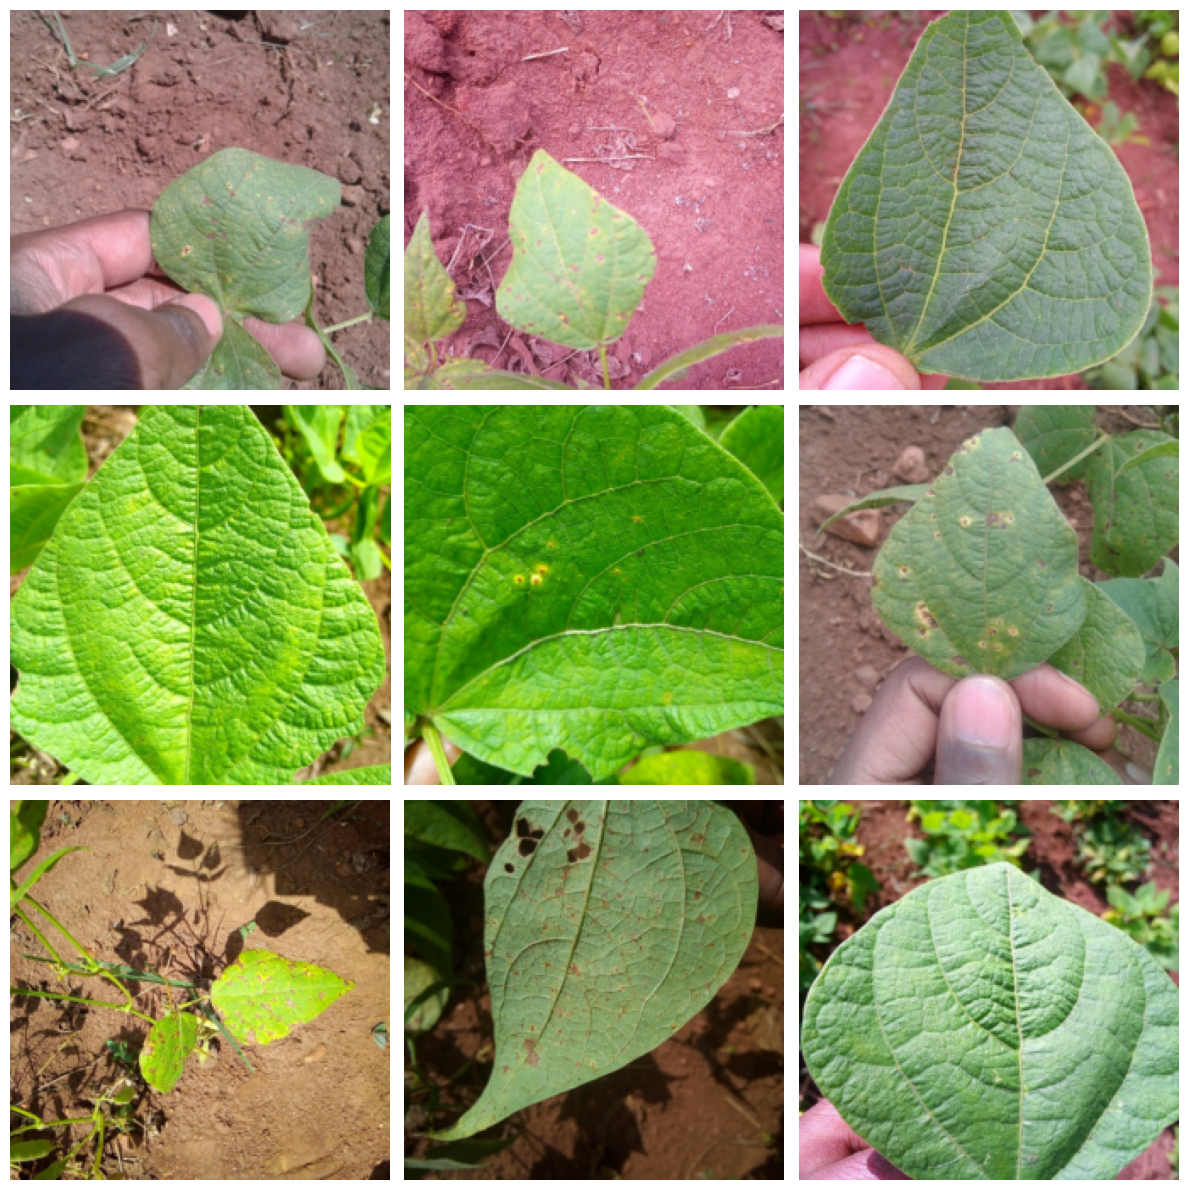

In [57]:
import numpy as np

n_rows = 3
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))

for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
        axes[row, col].imshow((image*255).squeeze().permute(1,2,0))  # Convert from (C, H, W) to (H, W, C) for displaying
        axes[row, col].axis('off') # Hide axes for better visualization
        
plt.tight_layout()
plt.show()

In [ ]:
LR = 1e-3
BATCH_SIZE = 1  # Reduced for GPU stability
EPOCHS = 15

In [59]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [60]:
google_net = torch.hub.load('pytorch/vision:v0.10.0', 'googlenet', pretrained=True)

Using cache found in C:\Users\lovep/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\lovep\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lovep\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [61]:
for param in google_net.parameters():
    param.requires_grad = True  # Unfreeze all layers for fine-tuning

In [62]:
google_net.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [63]:
num_classes = len(train_df['category'].unique())
num_classes  # Getting the number of unique categories in the dataset, which is 3 in this case

3

In [64]:
google_net.fc = torch.nn.Linear(google_net.fc.in_features, num_classes)
google_net.fc

Linear(in_features=1024, out_features=3, bias=True)

In [65]:
google_net.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [66]:
loss_fun = nn.CrossEntropyLoss() # CrossEntropyLoss is suitable for multi-class classification problems, which is the case here with 3 categories
optimizer = Adam(google_net.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = google_net(inputs)
        
        train_loss = loss_fun(outputs, labels)
        total_loss_train += train_loss.item()
        train_loss.backward()
        
        train_acc = (outputs.argmax(dim=1) == labels).sum().item() # Calculate number of correct predictions
        total_acc_train += train_acc
        optimizer.step()
        
    total_loss_train_plot.append(round(total_loss_train / 1000, 4)) # Average loss per batch
    total_acc_train_plot.append(round(total_acc_train / train_loader.dataset.__len__() * 100, 4)) # Average accuracy per sample
    print(f'''Epoch: {epoch+1}/{EPOCHS} | 
          Train Loss: {total_loss_train_plot[-1]} | 
          Train Accuracy: {total_acc_train_plot[-1]}%''')

RuntimeError: miopenStatusUnknownError